# XLand-MiniGrid Data Analysis


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from nicewebrl import data_analysis
from flax import serialization
import jax

In [5]:
from nicewebrl.utils import read_all_records

file_path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/minigrid-LLM-assistant/data/user_data_653394334.msgpack"
data_dicts = await read_all_records(file_path)

In [6]:
len(data_dicts)

24

In [7]:
from collections import Counter

# Count field frequencies inside "data"
field_counts = Counter(k for d in data_dicts for k in d.get("data", {}).keys())
print(field_counts.most_common(20))

# Peek at the last few records to see why [-1] didn't have action_taken_time
for d in data_dicts[-5:]:
  print(d.get("type"), list(d.get("data", {}).keys()))

[('image_seen_time', 24), ('action_taken_time', 24), ('computer_interaction', 24), ('action_name', 24), ('action_idx', 24), ('timelimit', 24), ('timestep', 24), ('llm_chat_history', 6)]
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'llm_chat_history']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']


In [8]:
def has_keys(d, *ks):
  return all(k in d.get("data", {}) for k in ks)


action_recs = [
  d for d in data_dicts if has_keys(d, "image_seen_time", "action_taken_time")
]
print(len(action_recs), "action timesteps")

24 action timesteps


In [10]:
from nicewebrl import time_diff


def has_str(d, key):
  v = d.get("data", {}).get(key)
  return isinstance(v, str) and len(v) > 0


# keep only *valid* action records with both times present as strings
action_recs = [
  d
  for d in data_dicts
  if has_str(d, "image_seen_time") and has_str(d, "action_taken_time")
]

# FIRST valid image_seen_time anywhere in the stream
first_image_ts = next(
  d["data"]["image_seen_time"] for d in data_dicts if has_str(d, "image_seen_time")
)

# LAST valid action_taken_time among action records
last_action_ts = next(d["data"]["action_taken_time"] for d in reversed(action_recs))

start_end_sec = time_diff(first_image_ts, last_action_ts) / 1000
print(f"Total seconds from first timestep to last action: {start_end_sec:.2f}")

pair_ms = [
  time_diff(d["data"]["image_seen_time"], d["data"]["action_taken_time"])
  for d in action_recs
]
total_timestep_sec = sum(pair_ms) / 1000
print(f"Total seconds across image–action pairs: {total_timestep_sec:.2f}")

Total seconds from first timestep to last action: 20.65
Total seconds across image–action pairs: 20.80


In [11]:
from pprint import pprint

datum = data_dicts[0]
print("-----")
pprint(list(datum.keys()))
print("--- data ---")
pprint(list(datum["data"].keys()))

-----
['stage_idx', 'session_id', 'data', 'user_data', 'metadata', 'name', 'body']
--- data ---
['image_seen_time',
 'action_taken_time',
 'computer_interaction',
 'action_name',
 'action_idx',
 'timelimit',
 'timestep']


In [13]:
print("------")

for key in [
  # "id",  # time-step idx. global
  "session_id",  # browser session id
  "stage_idx",
]:
  print(key, ":", datum[key])

print("--- data ---")
for key in [
  "image_seen_time",
  "action_taken_time",
  "computer_interaction",
  "action_name",
  "action_idx",
]:
  print(key, ":", datum["data"][key])

------
session_id : 630f37f7-578b-4561-a2a7-9f95c3223383
stage_idx : 1
--- data ---
image_seen_time : 2025-08-24T01:52:49.544Z
action_taken_time : 2025-08-24T01:52:51.233Z
computer_interaction : ArrowUp
action_name : Forward
action_idx : 2


In [14]:
datum["metadata"]  # remember, this is for the VERY FIRST timestep of this episode

{'desc': 'Navix Empty 8x8 with Gemini LLM hints',
 'grid_size': '8x8',
 'type': 'EnvStage',
 'unique_id': 'stage_73aec79cdf174524a708e3f3bd3ebc62',
 'nsteps': 2,
 'nepisodes': 1,
 'nsuccesses': 0}

In [15]:
datum["user_data"]

{'user_id': 653394334, 'age': None, 'sex': None}

In [16]:
def is_str(v):
  return isinstance(v, str) and len(v) > 0


img_idxs, img_ts = [], []
act_idxs, act_ts = [], []
for i, d in enumerate(data_dicts):
  dd = d.get("data", {})
  if is_str(dd.get("image_seen_time")):
    img_idxs.append(i)
    img_ts.append(dd["image_seen_time"])
  if is_str(dd.get("action_taken_time")):
    act_idxs.append(i)
    act_ts.append(dd["action_taken_time"])

print(f"records={len(data_dicts)}  images={len(img_idxs)}  actions={len(act_idxs)}")
print(
  "first image idx:",
  img_idxs[0] if img_idxs else None,
  "| ts:",
  img_ts[0] if img_ts else None,
)
print(
  "first action idx:",
  act_idxs[0] if act_idxs else None,
  "| ts:",
  act_ts[0] if act_ts else None,
)
print("image idxs (first 10):", img_idxs[:10])
print("action idxs (first 10):", act_idxs[:10])

records=24  images=24  actions=24
first image idx: 0 | ts: 2025-08-24T01:52:49.544Z
first action idx: 0 | ts: 2025-08-24T01:52:51.233Z
image idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
action idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [17]:
datum = data_dicts[0]["data"]
action_taken: int = datum["action_idx"]
image_seen_time: str = datum["image_seen_time"]
action_taken_time: str = datum["action_taken_time"]
reaction_time: float = data_analysis.compute_reaction_time(datum)

print(f"Reaction time: {reaction_time:.2f} milliseconds")

Reaction time: 1689.00 milliseconds


In [28]:
!pip uninstall -y navix
!pip install "git+https://github.com/epignatelli/navix.git@main"

  Cloning https://github.com/epignatelli/navix.git (to revision main) to /private/var/folders/__/8lk02q190nd3xjswcf9zbrvr0000gn/T/pip-req-build-m57dqpkv
  Running command git clone --filter=blob:none --quiet https://github.com/epignatelli/navix.git /private/var/folders/__/8lk02q190nd3xjswcf9zbrvr0000gn/T/pip-req-build-m57dqpkv
  Resolved https://github.com/epignatelli/navix.git to commit fe7f3ac4eb0f1ded698feffc3ef86c1bd39d1954
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for Navix: filename=navix-0.7.3-py2.py3-none-any.whl size=97573 sha256=c6f9cacb9162da90e0d09f521f4554251301787d300fbcd6f02b9b8822d73cb3
  Stored in directory: /private/var/folders/__/8lk02q190nd3xjswcf9zbrvr0000gn/T/pip-ephem-wheel-cache-fi4g2tqm/wheels/79/58/bc/fde667c2ae7befccbe75b38898e0016133eaaa36f8ba19dcdd
Successfully built Navix

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update

In [1]:
import navix as nx, inspect

print(nx.__file__)
print("has make?", hasattr(nx, "make"))
print("has observations?", hasattr(nx, "observations"))

/Users/vikramgoddla/.pyenv/versions/3.10.15/lib/python3.10/site-packages/navix/__init__.py
has make? True
has observations? True


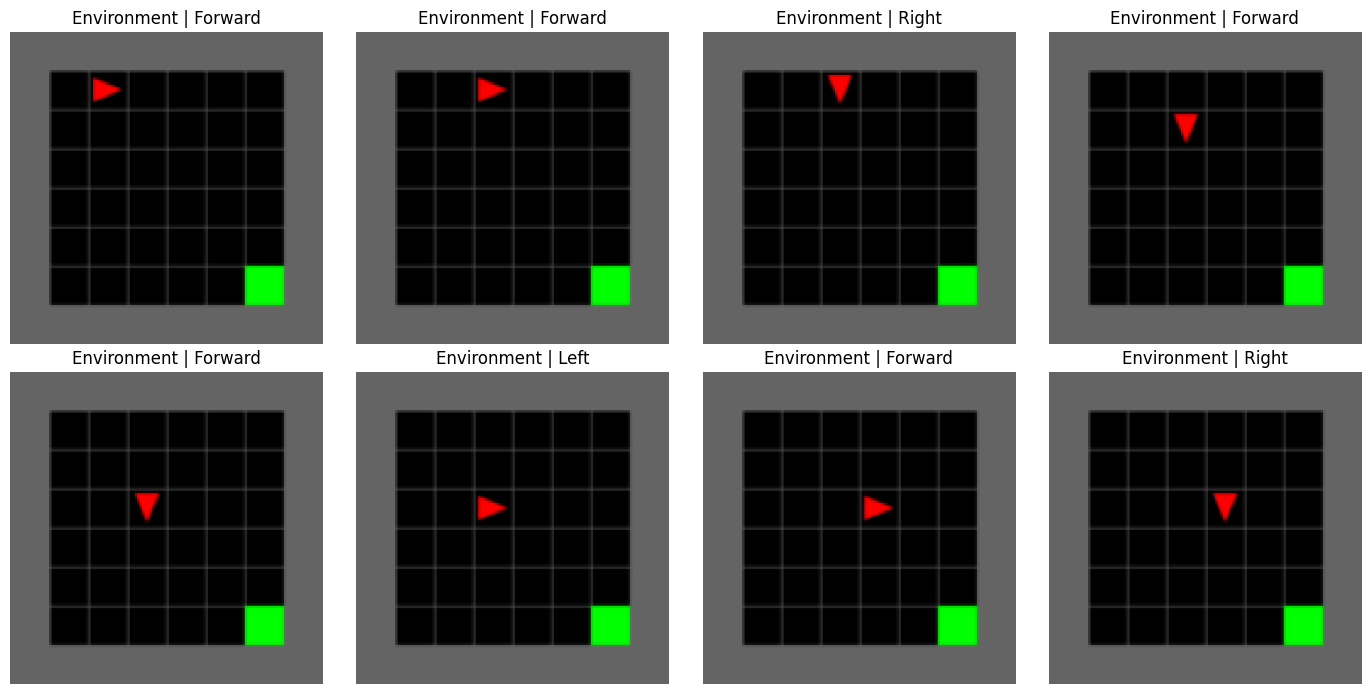

In [18]:
# --- Visualize sample timesteps from saved records (8x8 minigrid) ---

import numpy as np
import matplotlib.pyplot as plt
import jax
from flax import serialization

# 1) import the exact renderer/env you used in the app
from experiment_structure import render_fn as RENDER, jax_env, env_params

# 2) Build a template timestep for deserialization
example_timestep = jax_env.reset(key=jax.random.PRNGKey(0), params=env_params)


def show_timesteps(data_dicts, n=8):
  """Render first N saved timesteps as a grid."""
  assert RENDER is not None, "RENDER not found from experiment_structure.py"
  n = min(n, len(data_dicts))
  cols = min(4, n)
  rows = int(np.ceil(n / cols))
  fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
  axes = np.atleast_1d(axes).ravel()

  for i in range(n):
    rec = data_dicts[i]
    dd = rec.get("data", {}) or {}

    # deserialize the timestep (binary from msgpack)
    ts_bytes = dd["timestep"]
    timestep = serialization.from_bytes(example_timestep, ts_bytes)

    # render with the same fn your app used
    img = RENDER(timestep).astype(np.uint8)

    # small title with stage & action/key
    title = (
      f"{rec.get('name')} | {dd.get('action_name') or dd.get('computer_interaction')}"
    )
    ax = axes[i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title, wrap=True)

  for j in range(n, len(axes)):
    axes[j].axis("off")

  plt.tight_layout()
  plt.show()


# --- usage: assuming you've already loaded `data_dicts` from your msgpack/json ---
# e.g., from earlier cells in your notebook
show_timesteps(data_dicts, n=8)

In [19]:
import pandas as pd


def extract_latest_llm_turns(data_dicts):
  rows = []
  for rec in data_dicts:
    data = rec.get("data", {}) or {}
    hist = data.get("llm_chat_history")
    if not hist:
      continue
    if isinstance(hist, dict):
      hist = [hist]
    if not isinstance(hist, list):
      continue

    # only grab the latest turn in this record
    last = hist[-1]
    rows.append(
      {
        "timestamp": last.get("timestamp"),
        "stage": rec.get("name"),
        "turn": len(hist),
        "prompt": last.get("prompt") or "",
        "response": last.get("response") or "",
      }
    )

  df = pd.DataFrame(rows)
  if not df.empty:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # group by stage, keep only the first (latest turn seen per stage)
    df = df.groupby("stage", as_index=False).last()
    df = df.sort_values("timestamp").reset_index(drop=True)
  return df


df_llm = extract_latest_llm_turns(data_dicts)

if df_llm.empty:
  print("No LLM prompt history found.")
else:
  print(f"Unique prompt submissions found: {len(df_llm)}")
  display(df_llm[["timestamp", "stage", "turn", "prompt", "response"]])

Unique prompt submissions found: 1


,timestamp,stage,turn,prompt,response
0,2025-08-24 01:53:05.561814+00:00,Environment,1,what am i supposed to do here?,"As an assistant, I can help you navigate throu..."
